# Todesfälle nach Stadtquartier
bev_todesfaelle_jahr_quartier_od4220

### Kurzbeschreibung
Todesfälle von Personen der wirtschaftlichen Wohnbevölkerung der Stadt Zürich nach Statistischem Stadtquartier und Jahr.

Datum: 11.03.2026


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_todesfaelle_jahr_quartier_od4220

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_quartier_od4220


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
#help(mypy_dv)
help(mypy_dl)

Help on module my_py_dataloading_functions:

NAME
    my_py_dataloading_functions

FUNCTIONS
    load_data(status, data_source, package_name, dataset_name, **kwargs)
        Diese Funktion importiert die gewünschten Daten je nach Status (Int/Prod) und Speicherort (Dropzone/Web) in Pandas ein.
        
        Parameter:
        - status (str): sind die Daten auf Integ ('int') oder auf Prod ('prod') zu beziehen? 
        - data_source (str): sind die Daten im Internet ('web'), LOSD ('ld') oder auf den Dropzones/Fileverzeichnis ('dropzone') zu beziehen?
        - package_name (str): Name des Packages. Dies entspricht dem Slug in der URL und auch dem Verzeichnisnamen auf der Dropzone. Z.B. 'bfs_bev_bildungsstand_seit1970_OD1002'
        - dataset_name (str): Name des Datensatzes (in CKAN der Ressource). z.B. "bev324od3242.csv"
        
        Optionale Parameter:
        - ckan_integ_url (str):  Pfad zur INT-Umgebung von CKAN. Default: 'https://data.integ.stadt-zuerich.ch/dataset/'
     

In [5]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [6]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [7]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [8]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [9]:
package_name = "bev_todesfaelle_jahr_quartier_od4220"

In [10]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV422OD4220"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_quartier_od4220/download/BEV422OD4220.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_quartier_od4220 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_todesfaelle_jahr_quartier_od4220 

data_source: web


In [11]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1993-01-01 00:00:00,1993-01-01 00:00:00
QuarSort,11,12
QuarLang,Rathaus,Hochschulen
AnzSterWir,31,21


Berechne weitere Attribute falls notwendig

In [12]:
data2betested = (
    data2betested
    .copy()
    .assign(
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
QuarSort                        int64
QuarLang                       object
AnzSterWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

In [13]:
data2betested.head(2).T

,1121,1095
StichtagDatJahr,2025-01-01 00:00:00,2025-01-01 00:00:00
QuarSort,123,31
QuarLang,Hirzenbach,Alt-Wiedikon
AnzSterWir,152,73
StichtagDatJahr_str,2025-01-01,2025-01-01
Jahr,2025-01-01 00:00:00,2025-01-01 00:00:00
Jahr_end,2025-12-31 00:00:00,2025-12-31 00:00:00
Jahr_nbr,2025,2025


Minimales und maximales Jahr im Datensatz

In [14]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2025


In [15]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993-12-31 und ein Maximumjahr von 2025-12-31


### Einfache Datentests

In [16]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1122 entries, 1121 to 0
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      1122 non-null   datetime64[ns]
 1   QuarSort             1122 non-null   int64         
 2   QuarLang             1122 non-null   object        
 3   AnzSterWir           1122 non-null   int64         
 4   StichtagDatJahr_str  1122 non-null   object        
 5   Jahr                 1122 non-null   datetime64[ns]
 6   Jahr_end             1122 non-null   datetime64[ns]
 7   Jahr_nbr             1122 non-null   int32         
dtypes: datetime64[ns](3), int32(1), int64(2), object(2)
memory usage: 204.1 KB


In [17]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 1,122 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [18]:
data2betested.describe()

,StichtagDatJahr,QuarSort,AnzSterWir,Jahr,Jahr_end,Jahr_nbr
count,1122,1122,1122,1122,1122,1122
mean,2008-12-31 15:16:21.818181888,65,104,2008-12-31 15:16:21.818181888,2009-12-30 21:05:27.272727296,2009
min,1993-01-01 00:00:00,11,3,1993-01-01 00:00:00,1993-12-31 00:00:00,1993
25%,2001-01-01 00:00:00,33,47,2001-01-01 00:00:00,2001-12-31 00:00:00,2001
50%,2009-01-01 00:00:00,67,94,2009-01-01 00:00:00,2009-12-31 00:00:00,2009
75%,2017-01-01 00:00:00,92,153,2017-01-01 00:00:00,2017-12-31 00:00:00,2017
max,2025-01-01 00:00:00,123,320,2025-01-01 00:00:00,2025-12-31 00:00:00,2025
std,NaN,36,70,NaN,NaN,10


Welches sind die Quartiere ohne Werte bei AnzSterWir?

In [19]:
data2betested[np.isnan(data2betested.AnzSterWir)]

,StichtagDatJahr,QuarSort,QuarLang,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [20]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [21]:
data2betested.index.year.unique()

Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [22]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [23]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,QuarSort,AnzSterWir,Jahr_nbr
count,"1,122","1,122","1,122"
mean,65,104,"2,009"
std,36,70,10
min,11,3,"1,993"
25%,33,47,"2,001"
50%,67,94,"2,009"
75%,92,153,"2,017"
max,123,320,"2,025"


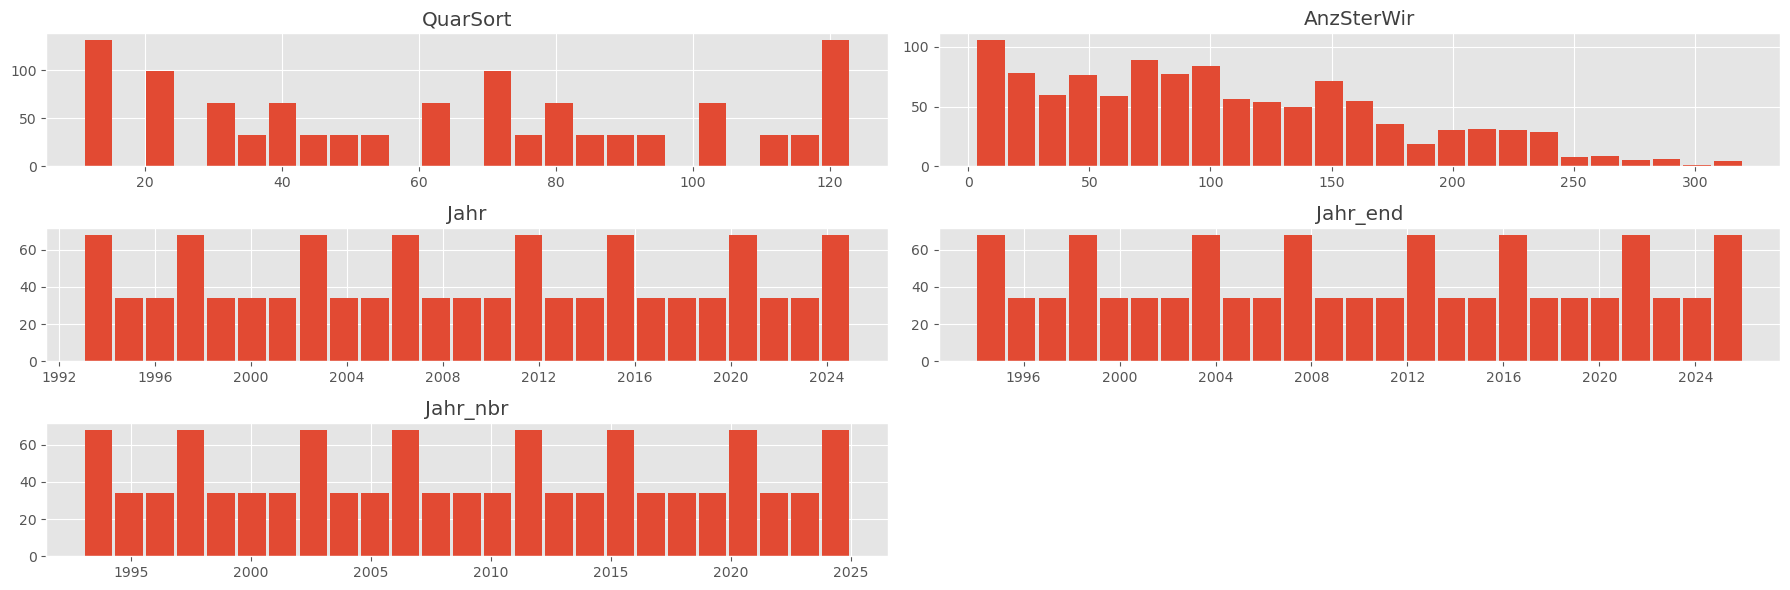

In [24]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [25]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,QuarSort,QuarLang,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,


### Nullwerte und Missings?

In [26]:
data2betested.isnull().sum()

QuarSort               0
QuarLang               0
AnzSterWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_end               0
Jahr_nbr               0
dtype: int64

In [27]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [28]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzSterWir
0,2025-01-01,2025,2025-12-31,3043
1,2024-01-01,2024,2024-12-31,3063
2,2023-01-01,2023,2023-12-31,3106


In [29]:
agg_quartier = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['QuarSort', 'QuarLang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('QuarSort', ascending=True) 
agg_quartier.reset_index().head(5)

,QuarSort,QuarLang,sum_AnzSterWir
0,11,Rathaus,627
1,12,Hochschulen,695
2,13,Lindenhof,219
3,14,City,241
4,21,Wollishofen,7877


In [30]:
agg_raum_zeit = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr_nbr', 'Jahr_end', 'QuarSort', 'QuarLang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('Jahr_nbr', ascending=True) 
agg_raum_zeit.reset_index().head(3)

,Jahr_nbr,Jahr_end,QuarSort,QuarLang,sum_AnzSterWir
0,1994,1994-12-31,11,Rathaus,25
1,1994,1994-12-31,73,Hirslanden,130
2,1994,1994-12-31,74,Witikon,137


In [31]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'QuarSort', 'QuarLang', 'AnzSterWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_end', 'Jahr_nbr'],
      dtype='object')

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

### Visualisierungen nach Zeitausschnitten

#### Entwicklung der Todesfälle nach Stadtquartier

In [33]:
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'QuarSort', 'QuarLang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,QuarSort,QuarLang,sum_AnzSterWir
0,1994-01-01,11,Rathaus,25
1,1994-01-01,73,Hirslanden,130
2,1994-01-01,74,Witikon,137


In [34]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('QuarSort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_AnzSterWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Todesfälle'
    ,category = "QuarLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung Todesfälle nach Stadtquartier, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

##### Kombinierte Grafik in Altair

In [35]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik1)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik1, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Barcharts mit Seaborn

In [ ]:
myAggBar = data2betested.loc[data_max_date]\
    .groupby(['StichtagDatJahr', 'QuarSort', 'QuarLang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values(['QuarSort'], ascending=[True]) 

myAggBar.reset_index().head(3)

In [ ]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

In [ ]:
myHist = sns.catplot(x="QuarLang"
            , y="sum_AnzSterWir"
            , kind="bar"
            , palette="pastel"
            , height=5
            , aspect=3
            , order=None, legend_out=True
            ,data=myAggBar.reset_index()
           )
myHist.set_xticklabels(rotation=45) 
myHist.set_xlabels('Stadtquartier', fontsize=11)
myHist.set_ylabels('Anz. Todesfälle', fontsize=11)

#### Faced Grids

In [ ]:
data2betested.columns

In [ ]:
myFG = data2betested.reset_index().query('QuarSort != 0')
myFG.head(3)

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarSort', ascending=True)
    ,col = "QuarLang"
    ,hue = "QuarLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzSterWir"
    ,ylabel= "Anzahl Todesfälle"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Todesfälle nach Stadtquartier, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [ ]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [ ]:
# Extrahiere die Stadtquartiere
attr2becolored = data2betested['QuarLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)

In [ ]:
data2betested.columns

##### Todesfälle nach Stadtquartier und Jahr

In [ ]:
myTM = data2betested.loc[data_min_date:data_max_date].reset_index()

myTM.reset_index().head(2)

In [ ]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index().query("AnzSterWir>0")
    ,levels=['QuarLang', 'Jahr_nbr']
    ,values="AnzSterWir"
    ,color="AnzSterWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey'}
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Stadtquartier und Jahr, seit "+data_min_date
)
treeMap1

##### Todesfälle nach Stadtquartier (aktuellstes Jahr)

In [ ]:
myTM2 = data2betested.loc[data_max_date]

myTM2.reset_index().head(2)

In [ ]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=myTM2.reset_index().query("AnzSterWir>0")
    ,levels=['QuarLang']
    ,values="AnzSterWir"
    ,color="QuarLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Stadtquartier am "+data_max_date
)
treeMap2

## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link]()**

---------------------------------------------------------------------------